<a href="https://colab.research.google.com/github/bastow-libby/379-Final-Project/blob/main/Final_Project_379.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import sqlite3
import glob
from datetime import datetime

# Suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

Extraction

In [26]:
# Stages of the ETL process are logged into this file
log_file = 'etl_log_file.txt'

# The names of the sqlite database and table to created to store the cleaned data
db_name = 'hr.db'
table_name = 'employees'

Examine the contents of the different types of files to see the formatting for extraction

In [27]:
# load one csv to discover its content, columns, etc.
df = pd.read_csv('ids_0.csv')

# display the data types of the columns
print(df.dtypes)

# display the head of the dataframe
df.head()

# print the columns
print(df.columns)

 Destination Port                 int64
 Flow Duration                    int64
 Total Fwd Packets                int64
 Total Backward Packets           int64
Total Length of Fwd Packets       int64
 Total Length of Bwd Packets      int64
 Fwd Packet Length Max            int64
 Fwd Packet Length Min            int64
 Fwd Packet Length Mean         float64
 Fwd Packet Length Std          float64
Bwd Packet Length Max             int64
 Bwd Packet Length Min            int64
 Bwd Packet Length Mean         float64
 Bwd Packet Length Std          float64
Flow Bytes/s                    float64
 Flow Packets/s                 float64
 Flow IAT Mean                  float64
 Flow IAT Std                   float64
 Flow IAT Max                     int64
 Flow IAT Min                     int64
Fwd IAT Total                     int64
 Fwd IAT Mean                   float64
 Fwd IAT Std                    float64
 Fwd IAT Max                      int64
 Fwd IAT Min                      int64


In [28]:
# load one json to discover its content, columns, etc.
df = pd.read_json('ids_4.json', lines=True)

# display the data types of the columns
print(df.dtypes)

# display the head of the dataframe
df.head()

 Destination Port                 int64
 Flow Duration                    int64
 Total Fwd Packets                int64
 Total Backward Packets           int64
Total Length of Fwd Packets       int64
 Total Length of Bwd Packets      int64
 Fwd Packet Length Max            int64
 Fwd Packet Length Min            int64
 Fwd Packet Length Mean         float64
 Fwd Packet Length Std          float64
Bwd Packet Length Max             int64
 Bwd Packet Length Min            int64
 Bwd Packet Length Mean         float64
 Bwd Packet Length Std          float64
Flow Bytes/s                    float64
 Flow Packets/s                 float64
 Flow IAT Mean                  float64
 Flow IAT Std                   float64
 Flow IAT Max                     int64
 Flow IAT Min                     int64
Fwd IAT Total                     int64
 Fwd IAT Mean                   float64
 Fwd IAT Std                    float64
 Fwd IAT Max                      int64
 Fwd IAT Min                      int64


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,27887,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,53,181,2,2,74,154,37,37,37.0,0.0,...,44,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,80,115,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,80,13,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,56529,50,1,1,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [29]:
# load one parquet to discover its content, columns, etc.
df = pd.read_parquet('ids_5.parquet')

# display the data types of the columns
print(df.dtypes)

# display the head of the dataframe
df.head()

 Destination Port                 int64
 Flow Duration                    int64
 Total Fwd Packets                int64
 Total Backward Packets           int64
Total Length of Fwd Packets       int64
 Total Length of Bwd Packets      int64
 Fwd Packet Length Max            int64
 Fwd Packet Length Min            int64
 Fwd Packet Length Mean         float64
 Fwd Packet Length Std          float64
Bwd Packet Length Max             int64
 Bwd Packet Length Min            int64
 Bwd Packet Length Mean         float64
 Bwd Packet Length Std          float64
Flow Bytes/s                    float64
 Flow Packets/s                 float64
 Flow IAT Mean                  float64
 Flow IAT Std                   float64
 Flow IAT Max                     int64
 Flow IAT Min                     int64
Fwd IAT Total                     int64
 Fwd IAT Mean                   float64
 Fwd IAT Std                    float64
 Fwd IAT Max                      int64
 Fwd IAT Min                      int64


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,14258,2,2,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DoS Hulk
1,80,116312384,6,6,423,11595,411,0,70.500000,166.836147,...,20,6999.0,0.0,6999,6999,58200000.0,59600000.0,100000000,16000000,DoS Hulk
2,80,3,2,0,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS Hulk
3,80,84082357,9,7,366,11595,366,0,40.666667,122.000000,...,32,995.0,0.0,995,995,83900000.0,0.0,83900000,83900000,DoS Hulk
4,80,2,2,0,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS Hulk


Since the columns appear to be the same, we will extract the data and then clean it

In [30]:
def extract() -> pd.DataFrame:
    """This function combines all the csv and json files into a dataframe

    Args:
        None: The function reads all csv and json files in the working directory

    Returns:
        data (pd.DataFrame): All data sources combined in a single dataframe
    """
    ## create an empty dataframe to hold all the data
    # The columns' names are given based on an earlier exploration of a csv file
    data = pd.DataFrame(columns=[' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count',
       ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count',
       ' ACK Flag Count', ' URG Flag Count', ' CWE Flag Count',
       ' ECE Flag Count', ' Down/Up Ratio', ' Average Packet Size',
       ' Avg Fwd Segment Size', ' Avg Bwd Segment Size',
       ' Fwd Header Length.1', 'Fwd Avg Bytes/Bulk', ' Fwd Avg Packets/Bulk',
       ' Fwd Avg Bulk Rate', ' Bwd Avg Bytes/Bulk', ' Bwd Avg Packets/Bulk',
       'Bwd Avg Bulk Rate', 'Subflow Fwd Packets', ' Subflow Fwd Bytes',
       ' Subflow Bwd Packets', ' Subflow Bwd Bytes', 'Init_Win_bytes_forward',
       ' Init_Win_bytes_backward', ' act_data_pkt_fwd',
       ' min_seg_size_forward', 'Active Mean', ' Active Std', ' Active Max',
       ' Active Min', 'Idle Mean', ' Idle Std', ' Idle Max', ' Idle Min',
       ' Label'])

    ## glob.glob('*.csv')
    #
    for csvfile in glob.glob('*.csv'):
        # load the current csv file into a temporary dataframe
        tmp_df = pd.read_csv(csvfile)

        # concatenate the loaded data with the data frame
        data = pd.concat([data, tmp_df], ignore_index=True)

    ## glob.glob('*.json')

    for jsonfile in glob.glob('*.json'):
        # load the current json file into a temporary dataframe
        tmp_df = pd.read_json(jsonfile, lines=True)

        # concatenate the loaded data to the data frame
        data = pd.concat([data, tmp_df], ignore_index=True)

    ## glob.glob ('*parquet')
    for parquetfile in glob.glob('*.parquet'):
        # load the current parquet file into a temporary dataframe
        tmp_df = pd.read_parquet(parquetfile)

        # concatenate the loaded data to the data frame
        data = pd.concat([data, tmp_df], ignore_index=True)

    # return the combined (extracted) data
    return data

In [31]:
data = extract()
print(data.dtypes)
print('data shape:', data.shape)
print('column names:', data.columns)

 Destination Port                object
 Flow Duration                   object
 Total Fwd Packets               object
 Total Backward Packets          object
Total Length of Fwd Packets      object
 Total Length of Bwd Packets     object
 Fwd Packet Length Max           object
 Fwd Packet Length Min           object
 Fwd Packet Length Mean         float64
 Fwd Packet Length Std          float64
Bwd Packet Length Max            object
 Bwd Packet Length Min           object
 Bwd Packet Length Mean         float64
 Bwd Packet Length Std          float64
Flow Bytes/s                    float64
 Flow Packets/s                 float64
 Flow IAT Mean                  float64
 Flow IAT Std                   float64
 Flow IAT Max                    object
 Flow IAT Min                    object
Fwd IAT Total                    object
 Fwd IAT Mean                   float64
 Fwd IAT Std                    float64
 Fwd IAT Max                     object
 Fwd IAT Min                     object


Transform Stage

First, we will identify any NaNs

In [32]:
from math import nan
import math
#Adjust the display function to see all columns
pd.options.display.max_rows = 500

print(data.isna().sum())

print(f'Total number of missing values: {data.isna().sum().sum()}')



 Destination Port                 0
 Flow Duration                    0
 Total Fwd Packets                0
 Total Backward Packets           0
Total Length of Fwd Packets       0
 Total Length of Bwd Packets      0
 Fwd Packet Length Max            0
 Fwd Packet Length Min            0
 Fwd Packet Length Mean           0
 Fwd Packet Length Std            0
Bwd Packet Length Max             0
 Bwd Packet Length Min            0
 Bwd Packet Length Mean           0
 Bwd Packet Length Std            0
Flow Bytes/s                    118
 Flow Packets/s                  33
 Flow IAT Mean                    0
 Flow IAT Std                     0
 Flow IAT Max                     0
 Flow IAT Min                     0
Fwd IAT Total                     0
 Fwd IAT Mean                     0
 Fwd IAT Std                      0
 Fwd IAT Max                      0
 Fwd IAT Min                      0
Bwd IAT Total                     0
 Bwd IAT Mean                     0
 Bwd IAT Std                

Since there are so few missing values, and we are trying to identify each packet, we will drop the rows with missing values rather than fill them in with averages. First, though, we will turn all infinity values into NaNs and drop them as well.

In [33]:
data.dropna(inplace=True)

print(f'Total number of missing values: {data.isna().sum().sum()}')

Total number of missing values: 0


We also need to drop any duplicate entries

In [34]:
data = data.drop_duplicates()

Now, we need to drop all heartbleed instances, as they are not DoS attacks

In [35]:
data = data[data[' Label'] != 'Heartbleed']
print('data shape:', data.shape)

data shape: (49490, 79)


Next, we need to adjust the labels for all DoS attacks so they can be boolean (grouped together under attack rather than by label)

In [36]:

data[' Label'] = data[' Label'].where(data[' Label'] == 'BENIGN', 'ATTACK')

We need to convert the values to integers now

In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49490 entries, 0 to 63126
Data columns (total 79 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0    Destination Port             49490 non-null  object 
 1    Flow Duration                49490 non-null  object 
 2    Total Fwd Packets            49490 non-null  object 
 3    Total Backward Packets       49490 non-null  object 
 4   Total Length of Fwd Packets   49490 non-null  object 
 5    Total Length of Bwd Packets  49490 non-null  object 
 6    Fwd Packet Length Max        49490 non-null  object 
 7    Fwd Packet Length Min        49490 non-null  object 
 8    Fwd Packet Length Mean       49490 non-null  float64
 9    Fwd Packet Length Std        49490 non-null  float64
 10  Bwd Packet Length Max         49490 non-null  object 
 11   Bwd Packet Length Min        49490 non-null  object 
 12   Bwd Packet Length Mean       49490 non-null  float64
 13   Bwd P

In [38]:
# Convert to int separated for clarity and cleanliness of code
def convert_to_int(x):
    return int(x)


In [39]:
for column in data.columns[:-1]: #iterate over all columns up to the last one
    if data[column].dtype == object:
        data[column] = data[column].apply(lambda x: convert_to_int(x))


In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49490 entries, 0 to 63126
Data columns (total 79 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0    Destination Port             49490 non-null  int64  
 1    Flow Duration                49490 non-null  int64  
 2    Total Fwd Packets            49490 non-null  int64  
 3    Total Backward Packets       49490 non-null  int64  
 4   Total Length of Fwd Packets   49490 non-null  int64  
 5    Total Length of Bwd Packets  49490 non-null  int64  
 6    Fwd Packet Length Max        49490 non-null  int64  
 7    Fwd Packet Length Min        49490 non-null  int64  
 8    Fwd Packet Length Mean       49490 non-null  float64
 9    Fwd Packet Length Std        49490 non-null  float64
 10  Bwd Packet Length Max         49490 non-null  int64  
 11   Bwd Packet Length Min        49490 non-null  int64  
 12   Bwd Packet Length Mean       49490 non-null  float64
 13   Bwd P

We will also look at the correlation between the columns to reduce dimensionality.

In [41]:
data.iloc[:, :-1].corr().style.background_gradient(cmap='coolwarm') #iloc method found on stack exchange

According to my research, rows/columns with NaN have 0 variance, meaning all the values are the same and can be eliminated. We also want to reduce columns that have high correlation.

In [42]:
data = data.loc[:, data.nunique() > 1] # Command to drop non-unique values from geeks for geek

In [43]:
data.iloc[:, :-1].corr().style.background_gradient(cmap='coolwarm') #iloc method found on stack exchange

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
Destination Port,1.000000,-0.147207,-0.005303,-0.003633,0.028000,-0.003539,0.036806,0.002539,0.080516,0.039276,-0.167625,-0.015847,-0.180413,-0.162583,0.094043,0.347788,-0.071498,-0.114751,-0.133121,-0.031750,-0.139459,-0.087755,-0.111738,-0.132006,-0.036158,-0.054428,-0.046839,-0.046758,-0.048761,-0.010533,0.153804,-0.008642,-0.005713,0.334497,0.165810,-0.005250,-0.155567,-0.165435,-0.161339,-0.121857,-0.047516,0.153804,-0.000388,-0.106972,0.154918,0.343404,-0.000388,0.044285,-0.163927,0.080516,-0.180413,-0.008642,-0.005303,0.028000,-0.003633,-0.003539,-0.085084,0.169696,-0.001634,-0.073356,-0.041318,-0.011370,-0.041345,-0.039704,-0.126190,-0.027487,-0.130300,-0.121600
Flow Duration,-0.147207,1.000000,0.019574,0.018122,0.050841,0.016611,0.143793,-0.113083,0.026795,0.163437,0.208112,-0.196254,0.242411,0.138188,-0.032738,-0.109392,0.379150,0.856165,0.964136,0.101413,0.999004,0.553739,0.860594,0.964382,0.165829,0.416433,0.342548,0.407062,0.424235,0.070189,-0.123448,0.023673,0.022543,-0.103891,-0.059752,-0.154537,0.216399,0.273498,0.207267,0.117163,0.310801,-0.123448,-0.005010,-0.457190,0.322597,-0.178630,-0.005010,-0.036004,0.261068,0.026795,0.242411,0.023673,0.019574,0.050841,0.018122,0.016615,-0.459049,-0.062468,0.015331,-0.247693,0.077624,0.084565,0.092138,0.060829,0.939713,0.178417,0.963767,0.909951
Total Fwd Packets,-0.005303,0.019574,1.000000,0.999252,0.506530,0.998954,0.021473,-0.004607,-0.000587,0.003708,0.024868,-0.006427,0.021085,0.005651,-0.000763,-0.003527,-0.012173,-0.004789,-0.003899,-0.009710,0.018923,-0.012877,-0.002659,-0.003886,-0.011091,0.027883,-0.002357,-0.003612,-0.000773,0.002136,0.045231,0.999120,0.998552,-0.003276,-0.002291,-0.006206,0.025077,0.026275,0.011237,0.004921,-0.006562,0.045231,0.000031,0.005783,0.003000,-0.007748,0.000031,0.003573,0.023398,-0.000587,0.021085,0.999120,1.000000,0.506530,0.999252,0.998946,0.005251,0.002249,0.998758,-0.012157,0.005940,0.010296,0.008549,0.004000,-0.004464,0.001723,-0.004171,-0.004629
Total Backward Packets,-0.003633,0.018122,0.999252,1.000000,0.506428,0.998759,0.021131,-0.003025,-0.000554,0.004242,0.024347,-0.003202,0.020915,0.004334,-0.000478,-0.003190,-0.010990,-0.003679,-0.002764,-0.008333,0.017673,-0.009867,-0.000735,-0.002757,-0.008958,0.031586,-0.001721,0.000183,0.003574,-0.001735,0.047103,0.997940,0.999571,-0.003127,-0.001258,-0.004395,0.024483,0.029635,0.011656,0.004419,0.000280,0.047103,0.000002,-0.000808,0.002898,-0.004757,0.000002,0.016847,0.027051,-0.000554,0.020915,0.997940,0.999252,0.506428,1.000000,0.998757,-0.001132,0.000506,0.998627,-0.019491,-0.005193,0.003022,-0.003367,-0.005698,-0.002368,-0.004155,-0.003041,-0.001868
Total Length of Fwd Packets,0.028000,0.050841,0.506530,0.506428,1.000000,0.494400,0.371884,0.020896,0.351578,0.336013,0.037696,-0.027014,0.032646,0.020933,0.008190,-0.014907,-0.048824,0.001209,-0.002576,-0.046966,0.047683,

In [44]:
import numpy as np

#Following code found on stack exchange to remove highly correlated columns
corr_matrix = data.iloc[:, :-1].corr().abs() #Build matrix

#Only examine the upper half of the matrix so we don't delete all columns
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.90
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
print(to_drop)
# Apply list of features to drop to matrix
data.drop(to_drop, axis=1, inplace=True)

[' Total Backward Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Std', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', ' Flow IAT Max', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Max', ' Fwd IAT Min', ' Bwd IAT Std', ' Bwd IAT Max', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', ' SYN Flag Count', ' ECE Flag Count', ' Average Packet Size', ' Avg Fwd Segment Size', ' Avg Bwd Segment Size', ' Fwd Header Length.1', 'Subflow Fwd Packets', ' Subflow Fwd Bytes', ' Subflow Bwd Packets', ' Subflow Bwd Bytes', 'Init_Win_bytes_forward', ' act_data_pkt_fwd', ' Active Max', ' Active Min', 'Idle Mean', ' Idle Max', ' Idle Min']


In [45]:
data.iloc[:, :-1].corr().style.background_gradient(cmap='coolwarm') #iloc method found on stack exchange

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Bwd Packet Length Max,Bwd Packet Length Min,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Min,Fwd IAT Std,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Min,Fwd PSH Flags,Bwd Packets/s,Min Packet Length,FIN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Init_Win_bytes_backward,min_seg_size_forward,Active Mean,Active Std,Idle Std
Destination Port,1.000000,-0.147207,-0.005303,0.028000,0.036806,0.002539,0.080516,-0.167625,-0.015847,0.094043,0.347788,-0.071498,-0.114751,-0.031750,-0.111738,-0.054428,-0.046839,-0.010533,0.153804,0.165810,-0.005250,-0.047516,-0.000388,-0.106972,0.154918,0.343404,0.044285,0.169696,-0.073356,-0.041318,-0.011370,-0.027487
Flow Duration,-0.147207,1.000000,0.019574,0.050841,0.143793,-0.113083,0.026795,0.208112,-0.196254,-0.032738,-0.109392,0.379150,0.856165,0.101413,0.860594,0.416433,0.342548,0.070189,-0.123448,-0.059752,-0.154537,0.310801,-0.005010,-0.457190,0.322597,-0.178630,-0.036004,-0.062468,-0.247693,0.077624,0.084565,0.178417
Total Fwd Packets,-0.005303,0.019574,1.000000,0.506530,0.021473,-0.004607,-0.000587,0.024868,-0.006427,-0.000763,-0.003527,-0.012173,-0.004789,-0.009710,-0.002659,0.027883,-0.002357,0.002136,0.045231,-0.002291,-0.006206,-0.006562,0.000031,0.005783,0.003000,-0.007748,0.003573,0.002249,-0.012157,0.005940,0.010296,0.001723
Total Length of Fwd Packets,0.028000,0.050841,0.506530,1.000000,0.371884,0.020896,0.351578,0.037696,-0.027014,0.008190,-0.014907,-0.048824,0.001209,-0.046966,0.002604,0.107289,0.068346,0.087898,0.054423,-0.006234,-0.003157,-0.015393,0.001921,0.061416,-0.034091,-0.018903,-0.003339,0.128334,-0.024992,0.033775,0.230874,0.008350
Fwd Packet Length Max,0.036806,0.143793,0.021473,0.371884,1.000000,0.107201,0.742221,0.352161,-0.146933,0.064856,-0.066258,-0.174717,0.189711,-0.225912,0.197284,0.237042,0.183926,-0.002487,-0.018093,-0.020749,-0.050931,0.011963,0.009816,0.203469,-0.132261,-0.104977,0.009537,0.029809,-0.070024,-0.179168,0.085603,-0.095350
Fwd Packet Length Min,0.002539,-0.113083,-0.004607,0.020896,0.107201,1.000000,0.567499,-0.122541,0.110803,0.293297,0.048480,-0.037194,-0.091628,-0.006045,-0.092897,-0.051808,-0.036636,0.011422,0.401050,0.138782,0.451296,-0.039192,-0.000470,-0.084470,0.056939,0.217338,0.079134,-0.010475,0.014296,-0.030974,-0.008794,-0.021525
Fwd Packet Length Mean,0.080516,0.026795,-0.000587,0.351578,0.742221,0.567499,1.000000,0.047263,-0.026826,0.214806,-0.001809,-0.077739,0.110517,-0.140021,0.031088,0.154728,0.167291,0.101958,0.209515,0.057479,0.196259,0.001323,0.005012,0.100997,-0.081839,0.049111,0.095501,0.073940,-0.023140,-0.075129,0.203469,-0.047682
Bwd Packet Length Max,-0.167625,0.208112,0.024868,0.037696,0.352161,-0.122541,0.047263,1.000000,-0.211195,-0.031715,-0.113722,-0.274338,0.224698,-0.278718,0.358284,0.142416,-0.005619,-0.095048,-0.168298,-0.061027,-0.177358,0.160262,-0.003409,0.097840,-0.106840,-0.174473,0.024554,-0.107217,-0.179035,-0.287419,-0.069696,-0.121280
Bwd Packet Length Min,-0.015847,-0.196254,-0.006427,-0.027014,-0.146933,0.110803,-0.026826,-0.211195,1.000000,0.001162,-0.004394,-0.083159,-0.140804,-0.041521,-0.159928,-0.083917,-0.049482,0.053300,-0.002451,0.024048,0.254611,-0.074935,-0.000818,-0.146952,-0.131696,-0.014975,0.184421,-0.019143,-0.064117,-0.053271,-0.013643,-0.034722
Flow Bytes/s,0.094043,-0.032738,-0.000763,0.008190,0.064856,0.293297,0.214806,-0.031715,0.001162,1.000000,0.338183,-0.015188,-0.025583,-0.006475,-0.025161,-0.014684,-0.012024,-0.002288,0.159353,0.243706,0.002398,-0.011579,-0.000126,-0.020458,0.026783,-0.002899,0.007896,-0.003040,0.000860,-0.008397,-0.002417,-0.005895


In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49490 entries, 0 to 63126
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0    Destination Port            49490 non-null  int64  
 1    Flow Duration               49490 non-null  int64  
 2    Total Fwd Packets           49490 non-null  int64  
 3   Total Length of Fwd Packets  49490 non-null  int64  
 4    Fwd Packet Length Max       49490 non-null  int64  
 5    Fwd Packet Length Min       49490 non-null  int64  
 6    Fwd Packet Length Mean      49490 non-null  float64
 7   Bwd Packet Length Max        49490 non-null  int64  
 8    Bwd Packet Length Min       49490 non-null  int64  
 9   Flow Bytes/s                 49490 non-null  float64
 10   Flow Packets/s              49490 non-null  float64
 11   Flow IAT Mean               49490 non-null  float64
 12   Flow IAT Std                49490 non-null  float64
 13   Flow IAT Min        

Now we should have a cleaned data set that is properly labeled. We can now load the data to a csv file

In [47]:
# load to a csv file
def loadcsv(data: pd.DataFrame) -> None:
    """This function loads the argument dataframe into a csv file

    Args:
        data (pd.DataFrame): extracted nd transformed dataframe
    """
    data.to_csv('packet_ids.csv', index=False)

In [48]:
loadcsv(data)

In [50]:
data.columns

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       'Total Length of Fwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       'Bwd Packet Length Max', ' Bwd Packet Length Min', 'Flow Bytes/s',
       ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Min',
       ' Fwd IAT Std', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Min',
       'Fwd PSH Flags', ' Bwd Packets/s', ' Min Packet Length',
       'FIN Flag Count', ' RST Flag Count', ' PSH Flag Count',
       ' ACK Flag Count', ' URG Flag Count', ' Down/Up Ratio',
       ' Init_Win_bytes_backward', ' min_seg_size_forward', 'Active Mean',
       ' Active Std', ' Idle Std', ' Label'],
      dtype='object')

We will now split and standardize the data.

In [92]:
X = data[[' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       'Total Length of Fwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       'Bwd Packet Length Max', ' Bwd Packet Length Min', 'Flow Bytes/s',
       ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Min',
       ' Fwd IAT Std', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Min',
       'Fwd PSH Flags', ' Bwd Packets/s', ' Min Packet Length',
       'FIN Flag Count', ' RST Flag Count', ' PSH Flag Count',
       ' ACK Flag Count', ' URG Flag Count', ' Down/Up Ratio',
       ' Init_Win_bytes_backward', ' min_seg_size_forward', 'Active Mean',
       ' Active Std', ' Idle Std']]
X.shape # Confirm that the correct number of rows and columns are stored in X
Y = data[[' Label']]

In [54]:
print(data.info()) #Show types, non-null counts, etc
print(data.describe()) #Show statistical values for each column

<class 'pandas.core.frame.DataFrame'>
Index: 49490 entries, 0 to 63126
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0    Destination Port            49490 non-null  int64  
 1    Flow Duration               49490 non-null  int64  
 2    Total Fwd Packets           49490 non-null  int64  
 3   Total Length of Fwd Packets  49490 non-null  int64  
 4    Fwd Packet Length Max       49490 non-null  int64  
 5    Fwd Packet Length Min       49490 non-null  int64  
 6    Fwd Packet Length Mean      49490 non-null  float64
 7   Bwd Packet Length Max        49490 non-null  int64  
 8    Bwd Packet Length Min       49490 non-null  int64  
 9   Flow Bytes/s                 49490 non-null  float64
 10   Flow Packets/s              49490 non-null  float64
 11   Flow IAT Mean               49490 non-null  float64
 12   Flow IAT Std                49490 non-null  float64
 13   Flow IAT Min        

At this point, I notice that some of the flow values are infinity, meaning they are divided by zero. Since there are only 6 instances out of over 49000, we will delete them.

In [93]:

print("Inf values in X:", np.isinf(X).sum().sum())
print(np.isinf(X).sum())

Inf values in X: 6
 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
Total Length of Fwd Packets    0
 Fwd Packet Length Max         0
 Fwd Packet Length Min         0
 Fwd Packet Length Mean        0
Bwd Packet Length Max          0
 Bwd Packet Length Min         0
Flow Bytes/s                   3
 Flow Packets/s                3
 Flow IAT Mean                 0
 Flow IAT Std                  0
 Flow IAT Min                  0
 Fwd IAT Std                   0
Bwd IAT Total                  0
 Bwd IAT Mean                  0
 Bwd IAT Min                   0
Fwd PSH Flags                  0
 Bwd Packets/s                 0
 Min Packet Length             0
FIN Flag Count                 0
 RST Flag Count                0
 PSH Flag Count                0
 ACK Flag Count                0
 URG Flag Count                0
 Down/Up Ratio                 0
 Init_Win_bytes_backward       0
 min_seg_size_forward          0
Active Mean             

In [98]:
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
print("Inf values in X:", np.isinf(X).sum().sum())
# delete those same rows in y
Y = Y.loc[X.index]

Inf values in X: 0


In [99]:
# convert y into a numpy 1-dimensional array named target

# * use the methods to_numpy() and squeeze()
y2 = Y.to_numpy() #Convert df to numpy array
print(y2.shape) #Check to see shape of numpy array before squeeze
target = np.squeeze(y2) #Squeeze y2 to get target

# * check target's unique values and corresponding frequencies
unique, counts = np.unique(target, return_counts=True) #Geeks for Geeks used as reference
print("Unique Values:", unique)
print("Counts:", counts)

# * check the shape of the resulting variable target
print(target.shape) # check to make sure the correct number of rows are maintained

(49487, 1)
Unique Values: ['ATTACK' 'BENIGN']
Counts: [44541  4946]
(49487,)


Booleanize the target array to make it that attacks are 1 and benign data flows are 0

In [100]:
target = np.where(target=='ATTACK', 1,0) #If the value is ATTACK, replace with 1 for true, otherwise, 0 for false
unique, counts = np.unique(target, return_counts=True) #Geeks for Geeks used as reference
print("Unique Values:", unique)
print("Counts:", counts)

Unique Values: [0 1]
Counts: [ 4946 44541]


Now we will split the data set into test and training data sets

In [101]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=0.15, stratify=target, random_state=12)

print("X_train: ", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train: ", y_train.shape)
print("y_test: ", y_test.shape)


X_train:  (42063, 32)
X_test:  (7424, 32)
y_train:  (42063,)
y_test:  (7424,)


Standardize the data

In [102]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42063 entries, 24073 to 39609
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0    Destination Port            42063 non-null  int64  
 1    Flow Duration               42063 non-null  int64  
 2    Total Fwd Packets           42063 non-null  int64  
 3   Total Length of Fwd Packets  42063 non-null  int64  
 4    Fwd Packet Length Max       42063 non-null  int64  
 5    Fwd Packet Length Min       42063 non-null  int64  
 6    Fwd Packet Length Mean      42063 non-null  float64
 7   Bwd Packet Length Max        42063 non-null  int64  
 8    Bwd Packet Length Min       42063 non-null  int64  
 9   Flow Bytes/s                 42063 non-null  float64
 10   Flow Packets/s              42063 non-null  float64
 11   Flow IAT Mean               42063 non-null  float64
 12   Flow IAT Std                42063 non-null  float64
 13   Flow IAT Min    

In [103]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train) # use the preprocessing StandardScaler method from scikit

X_train_standard = scaler.transform(X_train)
X_test_standard = scaler.transform(X_test)

Try classifiers and adjust them to see which classifiers and training works best

In [104]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from xgboost import XGBClassifier

# set the number of estimators to 150
xgboost_classifier = XGBClassifier(n_estimators=150)

# fit the classifier using the training dataset
xgboost_classifier.fit(X_train_standard, y_train, verbose=False)

# make predictions using X_test
pred = xgboost_classifier.predict(X_test_standard)

# compute the measures
acc_xgboost1 = accuracy_score(y_test, pred)
f1score_xgboost1 = f1_score(y_test, pred)
precision_xgboost1 = precision_score(y_test, pred)
recall_xgboost1 = recall_score(y_test, pred)


# display the measures
print('-'*25)
print('XGBoost Model: 4 features')
print('-'*25)
print('Accuracy: {:.3f}'.format(acc_xgboost1))
print('Precision: {:.3f}'.format(precision_xgboost1))
print('Recall: {:.3f}'.format(recall_xgboost1))
print('F1-score: {:.3f}'.format(f1score_xgboost1))

-------------------------
XGBoost Model: 4 features
-------------------------
Accuracy: 1.000
Precision: 1.000
Recall: 1.000
F1-score: 1.000


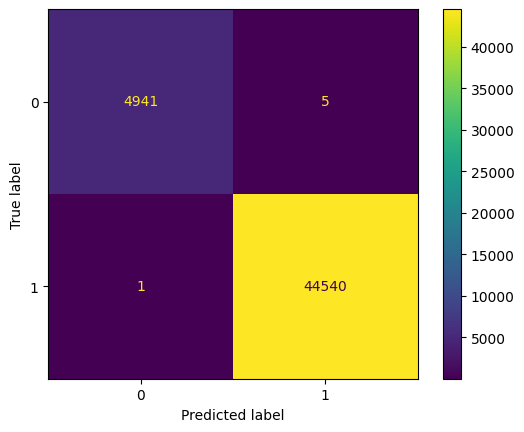

In [106]:
ConfusionMatrixDisplay.from_estimator(xgboost_classifier, np.concatenate((X_train_standard, X_test_standard), axis=0),
                                      np.concatenate((y_train, y_test)))